# Fashion-MNIST Vanilla CNN Baseline



In [1]:
# !pip install torch
# !pip install torchvision
# !pip install matplotlib

In [2]:
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")

# Data Loading

[data] Fashion-MNIST

- 28×28 grayscale 의류 이미지, 클래스 10개
- Train 60,000 / Test 10,000
- MNIST와 이미지 크기는 같고, 분류 난이도는 더 높음

In [3]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5,),  # 평균 0.5
            (0.5,),  # 표준편차 0.5
        ),
    ]
)

In [5]:
train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [6]:
# train_set 중 일부를 validation set으로 분리 (train 90% / valid 10%)
valid_ratio = 0.1
train_size = int(len(train_set) * (1 - valid_ratio))
valid_size = len(train_set) - train_size

train_subset, valid_subset = torch.utils.data.random_split(
    train_set,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

In [7]:
print(f"train_set size: {len(train_subset)}")
print(f"valid_set size: {len(valid_subset)}")
print(f"test_set size: {len(test_set)}")

train_set size: 54000
valid_set size: 6000
test_set size: 10000


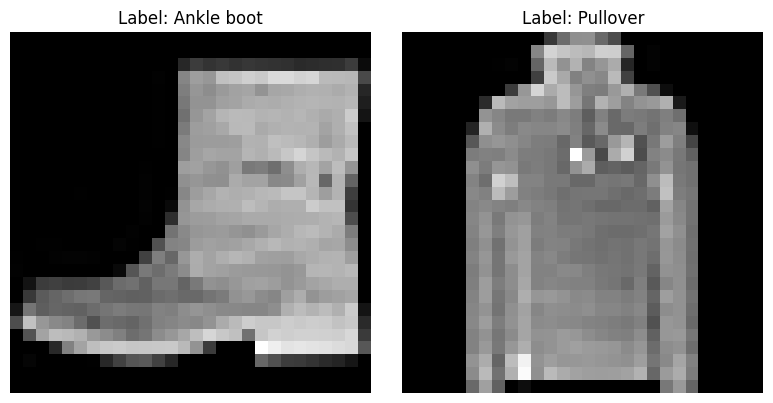

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
    image, label = train_subset[i]
    axes[i].imshow(image.squeeze(), cmap="gray")

    axes[i].set_title(f"Label: {CLASS_NAMES[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# CNN 반복 실험 기록

이 노트북은 **Base에서 시작해 한 번에 하나의 조건만 변경**하며 모델을 점진적으로 개선합니다.

각 실험은 `변경사항 → 가설 → 실험실행 → 결과 → 해석 → 시각화` 순서로 완결합니다. 다음 실험은 미리 정하지 않고, 직전 실험의 결과와 해석을 확인한 뒤 설계합니다.

## 공통 실험 원칙

- 데이터 분할과 random seed를 고정해 비교 조건을 맞춥니다.
- 한 실험에서는 하나의 요인만 변경합니다.
- 모델 선택과 실험 해석에는 validation 결과를 사용합니다.
- test set은 반복 실험 중 확인하지 않고, 최종 모델이 결정된 후 한 번만 평가합니다.
- 변경으로 성능이 개선되면 해당 설정을 다음 기준 모델로 채택하고, 개선되지 않으면 이전 최고 설정으로 돌아갑니다.

## 공통 함수

아래 코드는 Base와 이후 모든 실험에서 공통으로 사용합니다.

| 구성 | 역할 |
|---|---|
| `set_seed()` | 실험마다 난수 조건을 동일하게 설정 |
| `make_loaders()` | 기존 데이터 분할로 DataLoader 생성 |
| `FashionCNN` | 공통 CNN 모델 정의 |
| `evaluate()` | validation loss와 accuracy 계산 |
| `run_experiment()` | 학습, 검증, 최고 가중치 선택 수행 |
| `plot_comparison()` | epoch별 학습 곡선 비교 |
| `plot_best_valid_accuracy()` | 최고 validation accuracy 비교 |

In [9]:
import copy
import random


# 모델 두 개를 공정하게 비교하려면 난수 조건도 같아야 합니다.
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


# 사용 가능한 가속 장치가 있으면 자동으로 선택합니다.
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


# 이후 실험에서도 동일한 batch_size와 데이터 분할을 사용합니다.
def make_loaders(batch_size=256):
    # 기존에 생성한 train_subset, valid_subset, test_set을 그대로 사용합니다.
    return (
        torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0),
        torch.utils.data.DataLoader(valid_subset, batch_size=batch_size, shuffle=False, num_workers=0),
        torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0),
    )


# 모델 관련 실험에서도 재사용할 수 있도록 dropout_rate를 매개변수로 둡니다.
class FashionCNN(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        # 입력: (batch, 1, 28, 28)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 64 x 7 x 7 특징 맵을 1차원으로 변환
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # 0.0이면 Dropout이 사실상 적용되지 않음
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# 검증/테스트에서는 가중치를 수정하지 않고 손실과 정확도만 계산합니다.
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()  # Dropout 등 학습 전용 동작을 평가 모드로 전환
    total_loss = total_correct = total_count = 0
    predictions, targets = [], []
    with torch.no_grad():  # gradient를 저장하지 않아 메모리 사용량 감소
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            predicted = logits.argmax(dim=1)
            total_correct += (predicted == labels).sum().item()
            total_count += labels.size(0)

            if return_predictions:
                predictions.extend(predicted.cpu().tolist())
                targets.extend(labels.cpu().tolist())

    metrics = {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }
    if return_predictions:
        metrics.update({"predictions": predictions, "targets": targets})
    return metrics


# 모든 학습 과정을 하나의 함수로 묶어 다음 실험에서도 재사용합니다.
def run_experiment(
    name, dropout_rate, epochs=6, learning_rate=1e-3, seed=42, use_batchnorm=False
):
    set_seed(seed)
    device = get_device()
    train_loader, valid_loader, _ = make_loaders()

    model = FashionCNN(
        dropout_rate=dropout_rate, use_batchnorm=use_batchnorm
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
        "valid_accuracy": [],
    }
    best_state = None
    best_valid_accuracy = -1.0

    for epoch in range(epochs):
        model.train()
        total_loss = total_correct = total_count = 0

        for images, labels in train_loader:
            # 1) mini-batch를 학습 장치로 이동
            images, labels = images.to(device), labels.to(device)
            # 2) 이전 mini-batch의 gradient 초기화
            optimizer.zero_grad()
            # 3) 순전파 -> 손실 계산 -> 역전파 -> 가중치 갱신
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += labels.size(0)

        history["train_loss"].append(total_loss / total_count)
        history["train_accuracy"].append(total_correct / total_count)

        valid_metrics = evaluate(model, valid_loader, criterion, device)
        history["valid_loss"].append(valid_metrics["loss"])
        history["valid_accuracy"].append(valid_metrics["accuracy"])

        # 가장 높은 검증 정확도의 가중치를 기록합니다.
        if valid_metrics["accuracy"] > best_valid_accuracy:
            best_valid_accuracy = valid_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{name} | Epoch {epoch + 1:>2}/{epochs} | "
            f"train acc {history['train_accuracy'][-1]:.4f} | "
            f"valid acc {valid_metrics['accuracy']:.4f}"
        )

    # 반복 실험에서는 validation 결과로만 모델을 비교합니다.
    # test set은 모든 실험이 끝난 뒤 최종 모델 평가에 한 번만 사용합니다.
    model.load_state_dict(best_state)
    best_epoch = history["valid_accuracy"].index(best_valid_accuracy) + 1

    return {
        "name": name,
        "dropout_rate": dropout_rate,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "use_batchnorm": use_batchnorm,
        "use_batchnorm": use_batchnorm,
        "history": history,
        "best_epoch": best_epoch,
        "best_valid_accuracy": best_valid_accuracy,
        "model": model,
    }


def plot_comparison(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for result in results:
        history = result["history"]
        label = result["name"]
        # 실험마다 epoch 수가 달라도 각각의 x축 길이를 사용합니다.
        epochs = range(1, len(history["train_loss"]) + 1)

        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{label} train")
        axes[0].plot(epochs, history["valid_loss"], marker="s", linestyle="--", label=f"{label} valid")
        axes[1].plot(epochs, [x * 100 for x in history["train_accuracy"]], marker="o", label=f"{label} train")
        axes[1].plot(epochs, [x * 100 for x in history["valid_accuracy"]], marker="s", linestyle="--", label=f"{label} valid")

    axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy (%)")
    for axis in axes:
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()
    plt.show()




def plot_best_valid_accuracy(results):
    names = [result["name"] for result in results]
    accuracies = [result["best_valid_accuracy"] * 100 for result in results]
    colors = ["#6c757d", "#2a9d8f", "#457b9d", "#e9c46a"][:len(results)]
    bars = plt.bar(names, accuracies, color=colors)

    plt.ylim(max(0, min(accuracies) - 3), 100)
    plt.ylabel("Best validation accuracy (%)")
    plt.title("Best validation accuracy comparison")
    plt.xticks(rotation=10)

    for bar, value in zip(bars, accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.15,
            f"{value:.2f}%",
            ha="center",
        )

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Base

## Base_설정

아무 최적화 기법도 추가하지 않은 기본 CNN을 최초 기준점으로 사용합니다.

| 항목 | 설정값 |
|---|---|
| CNN 구조 | Conv-ReLU-Pool 블록 2개 |
| Dropout | 0.0 |
| Optimizer | Adam |
| Learning rate | 0.001 |
| Batch size | 256 |
| Epoch | 6 |
| Random seed | 42 |

이 설정은 실험 1의 비교 기준이며, 데이터 로드 및 전처리 코드는 변경하지 않습니다.

## Base_실험실행

공통 함수에 Base 설정값을 전달하여 학습합니다. 가장 높은 validation accuracy를 기록한 epoch의 가중치를 보관합니다.

In [10]:
base_result = run_experiment(
    name="Base (epochs=6)",
    dropout_rate=0.0,
    epochs=6,
    learning_rate=1e-3,
    seed=42,
)


Base (epochs=6) | Epoch  1/6 | train acc 0.7947 | valid acc 0.8625


Base (epochs=6) | Epoch  2/6 | train acc 0.8756 | valid acc 0.8862


Base (epochs=6) | Epoch  3/6 | train acc 0.8919 | valid acc 0.8888


Base (epochs=6) | Epoch  4/6 | train acc 0.9024 | valid acc 0.8978


Base (epochs=6) | Epoch  5/6 | train acc 0.9109 | valid acc 0.9077


Base (epochs=6) | Epoch  6/6 | train acc 0.9154 | valid acc 0.9085


## Base_결과

In [11]:
base_history = base_result["history"]
base_best_index = base_result["best_epoch"] - 1

print(f"Best epoch: {base_result['best_epoch']}")
print(f"Best validation accuracy: {base_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {base_history['valid_loss'][base_best_index]:.4f}")
print(f"Final train accuracy: {base_history['train_accuracy'][-1] * 100:.2f}%")
print(f"Final validation accuracy: {base_history['valid_accuracy'][-1] * 100:.2f}%")


Best epoch: 6
Best validation accuracy: 90.85%
Validation loss at best epoch: 0.2565
Final train accuracy: 91.54%
Final validation accuracy: 90.85%


## Base_해석

In [12]:
from IPython.display import Markdown, display

base_gap = (
    base_history["train_accuracy"][-1]
    - base_history["valid_accuracy"][-1]
) * 100

display(Markdown(
    f"- Base의 최고 validation accuracy는 **{base_result['best_valid_accuracy'] * 100:.2f}%**이며, "
    f"최고 성능은 **{base_result['best_epoch']} epoch**에서 기록되었습니다.\n"
    f"- 마지막 epoch의 train-validation accuracy 차이는 **{base_gap:.2f}%p**입니다.\n"
    "- 6 epoch까지만으로는 validation 성능이 충분히 수렴했는지, 이후 과적합이 발생하는지 판단하기 어렵습니다. "
    "따라서 실험 1에서는 다른 조건을 유지하고 epoch 수만 늘려 학습 흐름을 관찰합니다."
))


- Base의 최고 validation accuracy는 **90.85%**이며, 최고 성능은 **6 epoch**에서 기록되었습니다.
- 마지막 epoch의 train-validation accuracy 차이는 **0.69%p**입니다.
- 6 epoch까지만으로는 validation 성능이 충분히 수렴했는지, 이후 과적합이 발생하는지 판단하기 어렵습니다. 따라서 실험 1에서는 다른 조건을 유지하고 epoch 수만 늘려 학습 흐름을 관찰합니다.

## Base_시각화

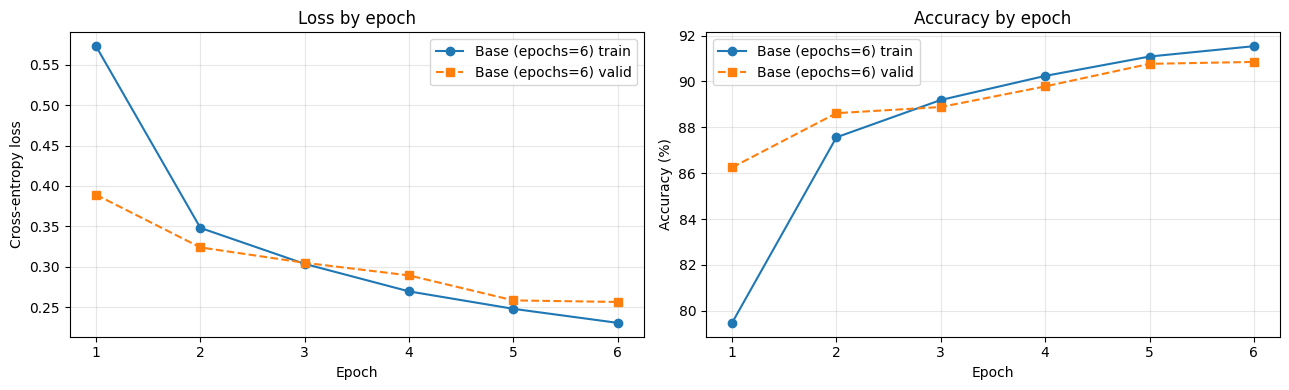

In [13]:
# Base 하나의 train/validation loss와 accuracy 변화를 확인합니다.
plot_comparison([base_result])


# 실험 1 - 적정 Epoch 탐색

## 실험1_변경사항

Base의 다른 조건은 유지하고 **최대 epoch만 6에서 30으로 확장**합니다. 하나의 모델을 30 epoch까지 학습하면서 매 epoch의 validation 지표를 기록합니다.

| 항목 | Base | 실험 1 |
|---|---:|---:|
| 최대 Epoch | 6 | **30** |
| Dropout | 0.0 | 0.0 |
| BatchNorm | 미적용 | 미적용 |
| Learning rate | 0.001 | 0.001 |
| Batch size | 256 | 256 |

독립변수는 최대 학습 횟수 하나입니다. 6, 15, 30 epoch 모델을 따로 학습하지 않고 한 번의 학습 이력에서 적정 시점을 찾습니다.

## 실험1_가설

> Base의 최고 validation accuracy가 마지막 6 epoch에서 기록되었으므로 학습이 충분히 수렴하지 않았을 가능성이 있다. 최대 30 epoch까지 학습하면 validation accuracy가 추가로 향상되지만, 일정 시점 이후에는 train-validation 차이와 validation loss가 증가하며 적정 종료 시점이 나타날 것이다.

## 실험1_실험실행

모델을 30 epoch까지 한 번 학습합니다. 이후 최고 validation accuracy와 최소 validation loss가 기록된 epoch를 각각 계산합니다.

In [9]:
experiment_1_result = run_experiment(
    name="Experiment 1 (epoch search)",
    dropout_rate=0.0,
    epochs=30,  # 탐색할 최대 epoch
    learning_rate=1e-3,
    seed=42,
    use_batchnorm=False,
)


Experiment 1 (epoch search) | Epoch  1/30 | train acc 0.7947 | valid acc 0.8625


Experiment 1 (epoch search) | Epoch  2/30 | train acc 0.8756 | valid acc 0.8862


Experiment 1 (epoch search) | Epoch  3/30 | train acc 0.8919 | valid acc 0.8888


Experiment 1 (epoch search) | Epoch  4/30 | train acc 0.9024 | valid acc 0.8978


Experiment 1 (epoch search) | Epoch  5/30 | train acc 0.9109 | valid acc 0.9077


...

Experiment 1 (epoch search) | Epoch 26/30 | train acc 0.9861 | valid acc 0.9278


Experiment 1 (epoch search) | Epoch 27/30 | train acc 0.9880 | valid acc 0.9252


Experiment 1 (epoch search) | Epoch 28/30 | train acc 0.9903 | valid acc 0.9228


Experiment 1 (epoch search) | Epoch 29/30 | train acc 0.9903 | valid acc 0.9225


Experiment 1 (epoch search) | Epoch 30/30 | train acc 0.9922 | valid acc 0.9245


## 실험1_결과

In [10]:
experiment_1_history = experiment_1_result["history"]
best_accuracy_epoch = experiment_1_result["best_epoch"]
min_loss_epoch = experiment_1_history["valid_loss"].index(
    min(experiment_1_history["valid_loss"])
) + 1
best_accuracy_index = best_accuracy_epoch - 1
min_loss_index = min_loss_epoch - 1

print(f"Best validation accuracy epoch: {best_accuracy_epoch}")
print(f"Best validation accuracy: {experiment_1_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best accuracy epoch: {experiment_1_history['valid_loss'][best_accuracy_index]:.4f}")
print(f"Minimum validation loss epoch: {min_loss_epoch}")
print(f"Minimum validation loss: {experiment_1_history['valid_loss'][min_loss_index]:.4f}")
print(f"Final train accuracy: {experiment_1_history['train_accuracy'][-1] * 100:.2f}%")
print(f"Final validation accuracy: {experiment_1_history['valid_accuracy'][-1] * 100:.2f}%")


Best validation accuracy epoch: 21
Best validation accuracy: 92.98%
Validation loss at best accuracy epoch: 0.2426
Minimum validation loss epoch: 12
Minimum validation loss: 0.2150
Final train accuracy: 99.22%
Final validation accuracy: 92.45%


## 실험1_해석

In [11]:
from IPython.display import Markdown, display

selected_epochs = best_accuracy_epoch
selected_index = selected_epochs - 1
selected_gap = (
    experiment_1_history["train_accuracy"][selected_index]
    - experiment_1_history["valid_accuracy"][selected_index]
) * 100
final_gap = (
    experiment_1_history["train_accuracy"][-1]
    - experiment_1_history["valid_accuracy"][-1]
) * 100

display(Markdown(
    f"- **가설 판단: 지지됨**\n"
    f"- 최고 validation accuracy는 **{best_accuracy_epoch} epoch**에서 "
    f"**{experiment_1_result['best_valid_accuracy'] * 100:.2f}%**로 나타났습니다.\n"
    f"- validation loss는 **{min_loss_epoch} epoch**에서 먼저 최솟값을 기록했습니다.\n"
    f"- 최고 정확도 시점의 train-validation 차이는 **{selected_gap:.2f}%p**, "
    f"30 epoch 시점에는 **{final_gap:.2f}%p**입니다.\n"
    f"- **실험 1 결론:** 분류 정확도를 주 지표로 사용하여 이후 비교 실험의 학습 횟수를 "
    f"**{selected_epochs} epoch로 고정**합니다."
))


- **가설 판단: 지지됨**
- 최고 validation accuracy는 **21 epoch**에서 **92.98%**로 나타났습니다.
- validation loss는 **12 epoch**에서 먼저 최솟값을 기록했습니다.
- 최고 정확도 시점의 train-validation 차이는 **4.38%p**, 30 epoch 시점에는 **6.77%p**입니다.
- **실험 1 결론:** 분류 정확도를 주 지표로 사용하여 이후 비교 실험의 학습 횟수를 **21 epoch로 고정**합니다.

## 실험1_시각화

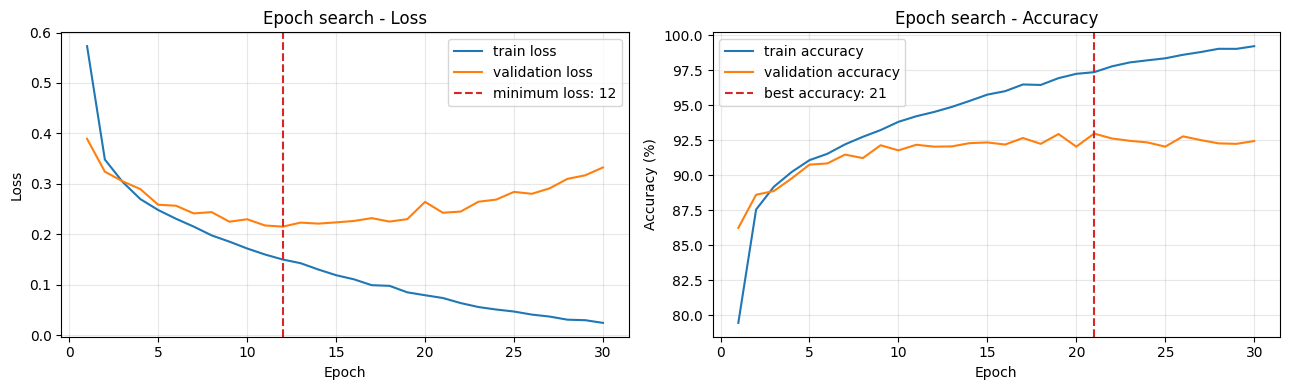

In [12]:
epochs = range(1, experiment_1_result["epochs"] + 1)
history = experiment_1_result["history"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["valid_loss"], label="validation loss")
axes[0].axvline(min_loss_epoch, color="tab:red", linestyle="--", label=f"minimum loss: {min_loss_epoch}")
axes[0].set(title="Epoch search - Loss", xlabel="Epoch", ylabel="Loss")

axes[1].plot(epochs, [v * 100 for v in history["train_accuracy"]], label="train accuracy")
axes[1].plot(epochs, [v * 100 for v in history["valid_accuracy"]], label="validation accuracy")
axes[1].axvline(best_accuracy_epoch, color="tab:red", linestyle="--", label=f"best accuracy: {best_accuracy_epoch}")
axes[1].set(title="Epoch search - Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()


# 실험 2 - 적정 Dropout 탐색

## 실험2_변경사항

실험 1에서 선택한 epoch를 고정하고, **Dropout 비율만 여러 후보로 변경**합니다.

- 후보: `0.0`, `0.1`, `0.2`, `0.3`, `0.4`
- 고정: CNN 구조, BatchNorm 미적용, Adam, learning rate 0.001, batch size 256, seed 42

여러 값을 실행하지만 변경하는 독립변수는 Dropout 하나이므로 하나의 실험으로 취급합니다. 각 후보는 서로 다른 학습 과정이므로 새 모델로 각각 학습합니다.

## 실험2_가설

> Dropout을 적용하면 Fully Connected Layer가 특정 특징에 과도하게 의존하는 현상이 줄어 validation loss와 train-validation 차이가 감소할 것이다. 너무 높은 비율은 필요한 특징 학습까지 방해하므로, 후보 중 중간 범위에서 가장 좋은 validation 성능이 나타날 것이다.

## 실험2_실험실행

동일한 함수와 seed를 사용해 다섯 개 Dropout 후보를 순서대로 학습합니다. 후보별 최고 validation accuracy 가중치를 기록합니다.

In [13]:
dropout_candidates = [0.0, 0.1, 0.2, 0.3, 0.4]

# Dropout 0.0은 실험 1과 동일한 모델이므로 선택된 epoch까지의 결과를 재사용합니다.
no_dropout_result = copy.deepcopy(experiment_1_result)
no_dropout_result["name"] = "Dropout 0.0"
no_dropout_result["epochs"] = selected_epochs
no_dropout_result["history"] = {
    key: values[:selected_epochs]
    for key, values in experiment_1_result["history"].items()
}
no_dropout_result["best_valid_accuracy"] = max(
    no_dropout_result["history"]["valid_accuracy"]
)
no_dropout_result["best_epoch"] = (
    no_dropout_result["history"]["valid_accuracy"].index(
        no_dropout_result["best_valid_accuracy"]
    ) + 1
)

dropout_results = {0.0: no_dropout_result}

for dropout_rate in dropout_candidates[1:]:
    print(f"\n===== Dropout {dropout_rate:.1f} =====")
    dropout_results[dropout_rate] = run_experiment(
        name=f"Dropout {dropout_rate:.1f}",
        dropout_rate=dropout_rate,
        epochs=selected_epochs,
        learning_rate=1e-3,
        seed=42,
        use_batchnorm=False,
    )



===== Dropout 0.1 =====


Dropout 0.1 | Epoch  1/21 | train acc 0.7875 | valid acc 0.8665


Dropout 0.1 | Epoch  2/21 | train acc 0.8712 | valid acc 0.8862


Dropout 0.1 | Epoch  3/21 | train acc 0.8884 | valid acc 0.8835


Dropout 0.1 | Epoch  4/21 | train acc 0.9007 | valid acc 0.9008


...

Dropout 0.4 | Epoch 17/21 | train acc 0.9421 | valid acc 0.9262


Dropout 0.4 | Epoch 18/21 | train acc 0.9444 | valid acc 0.9273


Dropout 0.4 | Epoch 19/21 | train acc 0.9476 | valid acc 0.9260


Dropout 0.4 | Epoch 20/21 | train acc 0.9487 | valid acc 0.9262


Dropout 0.4 | Epoch 21/21 | train acc 0.9505 | valid acc 0.9240


## 실험2_결과

In [14]:
dropout_summary = []

for dropout_rate, result in dropout_results.items():
    best_index = result["best_epoch"] - 1
    history = result["history"]
    valid_loss = history["valid_loss"][best_index]
    accuracy_gap = (
        history["train_accuracy"][best_index]
        - history["valid_accuracy"][best_index]
    ) * 100
    dropout_summary.append({
        "dropout": dropout_rate,
        "best_epoch": result["best_epoch"],
        "valid_accuracy": result["best_valid_accuracy"],
        "valid_loss": valid_loss,
        "accuracy_gap": accuracy_gap,
    })

print(f"{'Dropout':>8} {'Best epoch':>11} {'Valid acc':>11} {'Valid loss':>11} {'Gap':>9}")
print("-" * 56)
for row in dropout_summary:
    print(
        f"{row['dropout']:>8.1f} {row['best_epoch']:>11d} "
        f"{row['valid_accuracy'] * 100:>10.2f}% {row['valid_loss']:>11.4f} "
        f"{row['accuracy_gap']:>8.2f}%p"
    )

# 최고 정확도에서 0.1%p 이내인 후보는 동급으로 보고 validation loss로 최종 선택합니다.
maximum_accuracy = max(row["valid_accuracy"] for row in dropout_summary)
near_best_candidates = [
    row for row in dropout_summary
    if maximum_accuracy - row["valid_accuracy"] <= 0.001
]
selected_dropout_row = min(
    near_best_candidates,
    key=lambda row: (row["valid_loss"], row["accuracy_gap"], row["dropout"]),
)
selected_dropout = selected_dropout_row["dropout"]
selected_dropout_result = dropout_results[selected_dropout]

print(f"\nSelected dropout: {selected_dropout:.1f}")


 Dropout  Best epoch   Valid acc  Valid loss       Gap
--------------------------------------------------------
     0.0          21      92.98%      0.2426     4.38%p
     0.1          13      92.83%      0.2090     1.77%p
     0.2          18      92.95%      0.2146     2.93%p
     0.3          18      92.63%      0.2082     2.49%p
     0.4          18      92.73%      0.2062     1.71%p

Selected dropout: 0.2


## 실험2_해석

In [15]:
no_dropout_row = next(row for row in dropout_summary if row["dropout"] == 0.0)
accuracy_change = (
    selected_dropout_row["valid_accuracy"] - no_dropout_row["valid_accuracy"]
) * 100
loss_change = selected_dropout_row["valid_loss"] - no_dropout_row["valid_loss"]
gap_change = selected_dropout_row["accuracy_gap"] - no_dropout_row["accuracy_gap"]

display(Markdown(
    f"- 가장 높은 accuracy에서 0.1%p 이내인 후보 중 validation loss가 가장 낮은 값은 "
    f"**Dropout {selected_dropout:.1f}**입니다.\n"
    f"- Dropout 0.0 대비 validation accuracy 변화는 **{accuracy_change:+.2f}%p**입니다.\n"
    f"- Dropout 0.0 대비 validation loss 변화는 **{loss_change:+.4f}**, "
    f"train-validation 차이 변화는 **{gap_change:+.2f}%p**입니다.\n"
    f"- **실험 2 결론:** 이후 실험의 Dropout 비율을 **{selected_dropout:.1f}**로 고정합니다."
))


- 가장 높은 accuracy에서 0.1%p 이내인 후보 중 validation loss가 가장 낮은 값은 **Dropout 0.2**입니다.
- Dropout 0.0 대비 validation accuracy 변화는 **-0.03%p**입니다.
- Dropout 0.0 대비 validation loss 변화는 **-0.0280**, train-validation 차이 변화는 **-1.45%p**입니다.
- **실험 2 결론:** 이후 실험의 Dropout 비율을 **0.2**로 고정합니다.

## 실험2_시각화

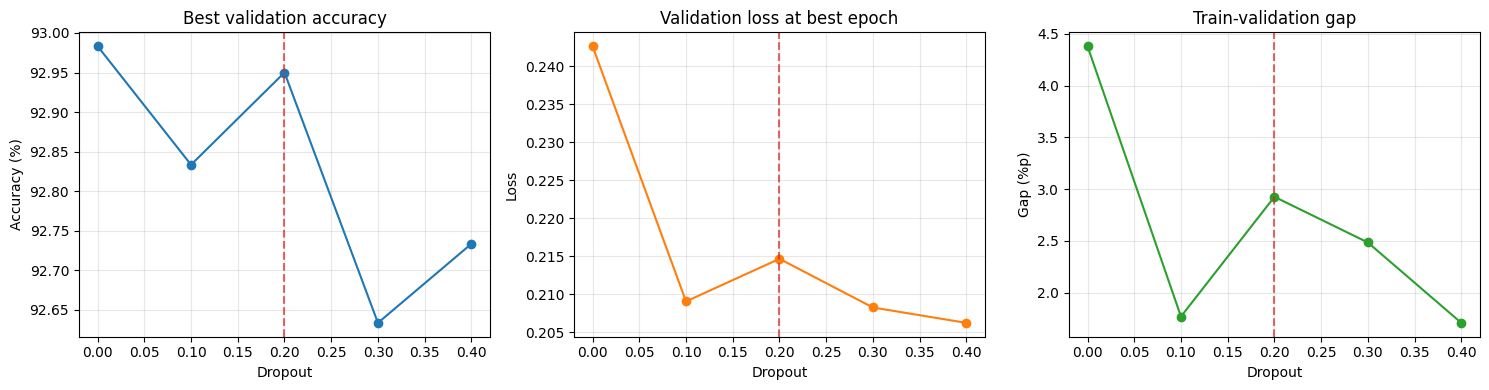

In [16]:
rates = [row["dropout"] for row in dropout_summary]
accuracies = [row["valid_accuracy"] * 100 for row in dropout_summary]
losses = [row["valid_loss"] for row in dropout_summary]
gaps = [row["accuracy_gap"] for row in dropout_summary]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(rates, accuracies, marker="o")
axes[0].set(title="Best validation accuracy", xlabel="Dropout", ylabel="Accuracy (%)")
axes[1].plot(rates, losses, marker="o", color="tab:orange")
axes[1].set(title="Validation loss at best epoch", xlabel="Dropout", ylabel="Loss")
axes[2].plot(rates, gaps, marker="o", color="tab:green")
axes[2].set(title="Train-validation gap", xlabel="Dropout", ylabel="Gap (%p)")

for axis in axes:
    axis.axvline(selected_dropout, color="tab:red", linestyle="--", alpha=0.7)
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 실험 3 - BatchNorm 적용

## 실험3_변경사항

실험 1과 2에서 선택한 `epochs=21`, `Dropout=0.2`를 유지하고, 각 합성곱 층 뒤에 **BatchNorm만 추가**합니다.

| 항목 | 실험 2 채택 모델 | 실험 3 |
|---|---:|---:|
| Epoch | 21 | 21 |
| Dropout | 0.2 | 0.2 |
| BatchNorm | 미적용 | **적용** |
| Learning rate | 0.001 | 0.001 |
| Batch size | 256 | 256 |

독립변수는 BatchNorm 적용 여부 하나이며, 다른 조건은 동일합니다.

## 실험3_가설

> BatchNorm을 합성곱 층 뒤에 적용하면 mini-batch 단위로 중간 특징의 분포가 정규화되어 학습이 안정화될 것이다. 이에 따라 Dropout 0.2만 적용한 모델보다 validation accuracy가 향상되거나 validation loss가 감소할 것이다.

BatchNorm은 규제 효과도 일부 가질 수 있지만, 이 실험에서는 학습 안정화와 검증 성능 변화를 중심으로 평가합니다.

## 실험3_실험실행

실험 2에서 선택된 Dropout 0.2 모델과 동일한 조건에서 `use_batchnorm=True`만 적용해 모델을 처음부터 학습합니다.

In [10]:
experiment_3_result = run_experiment(
    name="Experiment 3 (BatchNorm)",
    dropout_rate=selected_dropout,
    epochs=selected_epochs,
    learning_rate=1e-3,
    seed=42,
    use_batchnorm=True,  # 실험 2 채택 모델에서 변경한 유일한 조건
)


Experiment 3 (BatchNorm) | Epoch  1/21 | train acc 0.8336 | valid acc 0.8887


Experiment 3 (BatchNorm) | Epoch  2/21 | train acc 0.8924 | valid acc 0.9022


Experiment 3 (BatchNorm) | Epoch  3/21 | train acc 0.9079 | valid acc 0.8990


Experiment 3 (BatchNorm) | Epoch  4/21 | train acc 0.9170 | valid acc 0.9108


Experiment 3 (BatchNorm) | Epoch  5/21 | train acc 0.9244 | valid acc 0.9148


...

Experiment 3 (BatchNorm) | Epoch 17/21 | train acc 0.9711 | valid acc 0.9227


Experiment 3 (BatchNorm) | Epoch 18/21 | train acc 0.9711 | valid acc 0.9250


Experiment 3 (BatchNorm) | Epoch 19/21 | train acc 0.9743 | valid acc 0.9250


Experiment 3 (BatchNorm) | Epoch 20/21 | train acc 0.9754 | valid acc 0.9242


Experiment 3 (BatchNorm) | Epoch 21/21 | train acc 0.9786 | valid acc 0.9247


## 실험3_결과

In [11]:
reference_result = selected_dropout_result
reference_history = reference_result["history"]
experiment_3_history = experiment_3_result["history"]

reference_best_index = reference_result["best_epoch"] - 1
experiment_3_best_index = experiment_3_result["best_epoch"] - 1

reference_loss = reference_history["valid_loss"][reference_best_index]
experiment_3_loss = experiment_3_history["valid_loss"][experiment_3_best_index]
reference_gap = (
    reference_history["train_accuracy"][reference_best_index]
    - reference_history["valid_accuracy"][reference_best_index]
) * 100
experiment_3_gap = (
    experiment_3_history["train_accuracy"][experiment_3_best_index]
    - experiment_3_history["valid_accuracy"][experiment_3_best_index]
) * 100

validation_accuracy_change = (
    experiment_3_result["best_valid_accuracy"]
    - reference_result["best_valid_accuracy"]
) * 100
validation_loss_change = experiment_3_loss - reference_loss
gap_change = experiment_3_gap - reference_gap

print("[Experiment 2 selected - BatchNorm OFF]")
print(f"Dropout: {selected_dropout:.1f}")
print(f"Best epoch: {reference_result['best_epoch']}")
print(f"Best validation accuracy: {reference_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {reference_loss:.4f}")
print(f"Train-validation accuracy gap: {reference_gap:.2f}%p")

print("\n[Experiment 3 - BatchNorm ON]")
print(f"Dropout: {selected_dropout:.1f}")
print(f"Best epoch: {experiment_3_result['best_epoch']}")
print(f"Best validation accuracy: {experiment_3_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {experiment_3_loss:.4f}")
print(f"Train-validation accuracy gap: {experiment_3_gap:.2f}%p")
print(f"Validation accuracy change: {validation_accuracy_change:+.2f}%p")
print(f"Validation loss change: {validation_loss_change:+.4f}")
print(f"Accuracy gap change: {gap_change:+.2f}%p")


[Experiment 2 selected - BatchNorm OFF]
Dropout: 0.2
Best epoch: 18
Best validation accuracy: 92.95%
Validation loss at best epoch: 0.2146
Train-validation accuracy gap: 2.93%p

[Experiment 3 - BatchNorm ON]
Dropout: 0.2
Best epoch: 15
Best validation accuracy: 92.55%
Validation loss at best epoch: 0.2388
Train-validation accuracy gap: 3.98%p
Validation accuracy change: -0.40%p
Validation loss change: +0.0241
Accuracy gap change: +1.05%p


## 실험3_해석

In [12]:
from IPython.display import Markdown, display

accuracy_improved = validation_accuracy_change > 0
loss_improved = validation_loss_change < 0

if validation_accuracy_change > 0.2:
    hypothesis_judgement = "지지됨"
    adoption = "BatchNorm 적용 모델을 새로운 최고 모델로 채택합니다."
elif validation_accuracy_change >= -0.1 and loss_improved:
    hypothesis_judgement = "부분적으로 지지됨"
    adoption = "정확도는 유사하지만 validation loss가 개선되어 BatchNorm을 조건부 채택합니다."
else:
    hypothesis_judgement = "지지되지 않음"
    adoption = "BatchNorm을 채택하지 않고 실험 2의 설정을 유지합니다."

loss_sentence = (
    f"validation loss는 **{abs(validation_loss_change):.4f} 감소**했습니다."
    if loss_improved
    else f"validation loss는 **{validation_loss_change:.4f} 증가**했습니다."
)
gap_sentence = (
    f"train-validation 차이는 **{abs(gap_change):.2f}%p 감소**했습니다."
    if gap_change < 0
    else f"train-validation 차이는 **{gap_change:.2f}%p 증가**했습니다."
)

display(Markdown(
    f"- **가설 판단: {hypothesis_judgement}**\n"
    f"- BatchNorm 적용 후 최고 validation accuracy 변화는 **{validation_accuracy_change:+.2f}%p**입니다.\n"
    f"- {loss_sentence}\n"
    f"- {gap_sentence}\n"
    f"- **실험 3 결론:** {adoption}"
))


- **가설 판단: 지지되지 않음**
- BatchNorm 적용 후 최고 validation accuracy 변화는 **-0.40%p**입니다.
- validation loss는 **0.0241 증가**했습니다.
- train-validation 차이는 **1.05%p 증가**했습니다.
- **실험 3 결론:** BatchNorm을 채택하지 않고 실험 2의 설정을 유지합니다.

## 실험3_시각화

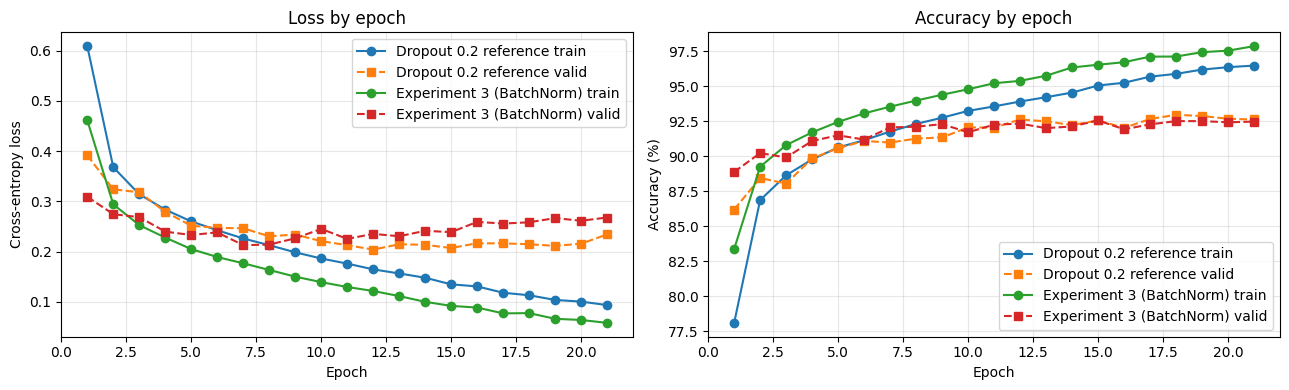

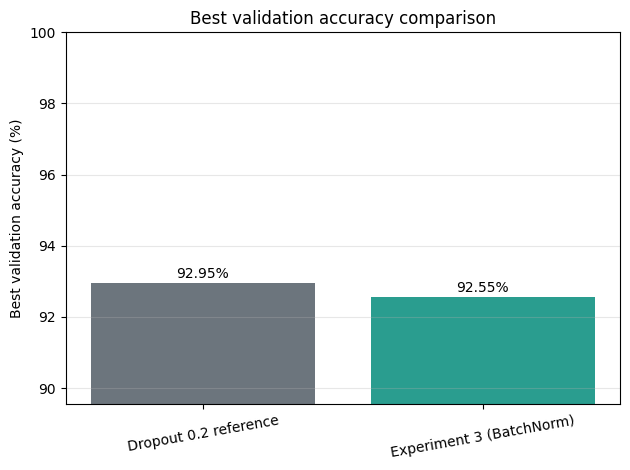

In [13]:
batchnorm_results = [reference_result, experiment_3_result]

# BatchNorm 적용 전후의 epoch별 학습 곡선 비교
plot_comparison(batchnorm_results)

# BatchNorm 적용 전후의 최고 validation accuracy 비교
plot_best_valid_accuracy(batchnorm_results)


# 실험 4 - Layer 너비 탐색 (기획)

## 실험4_변경사항

실험 2에서 채택하고 실험 3에서도 유지하기로 한 설정을 기준 모델로 사용합니다.

- Epoch: 21
- Dropout: 0.2
- BatchNorm: 미적용
- Optimizer: Adam
- Learning rate: 0.001

이번에는 **Fully Connected Layer의 hidden unit 수만 변경**합니다.

- 후보: `64`, `128`, `256`
- 현재 기준값: `128`

여러 후보를 한 번에 학습하지만 변경하는 독립변수는 Layer 너비 하나입니다. 합성곱 층, Dropout, optimizer 등 다른 조건은 동일하게 유지합니다.

## 실험4_가설

> 현재 모델은 학습 데이터와 검증 데이터 사이에 성능 차이가 남아 있다. Fully Connected Layer의 hidden unit을 128보다 작은 64로 줄이면 모델의 표현 용량과 파라미터 수가 감소해 과적합이 완화될 수 있다. 반대로 256으로 늘리면 표현력은 증가하지만 과적합이 심해질 가능성이 있다. 따라서 64 또는 128에서 validation accuracy와 validation loss의 균형이 가장 좋을 것이다.

실험 결과는 최고 validation accuracy를 주 지표로 평가하고, validation loss와 train-validation 차이, 모델 파라미터 수를 보조 지표로 비교할 예정입니다.